In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

C:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv(r'../pre-calculated_data/property.csv')
df.loc[df['City'].str.startswith('NanJing'), 'Site'] = 'NanJing'
df.loc[df['City'].str.startswith('ShangHai'), 'Site'] = 'ShangHai'
df

,Sample,Electric conductivity(us/cm),All carbon(g/kg),Organic carbon(g/kg),N(g/kg),P(g/kg),K(g/kg),City,Location,Site
0,cpsnj01,168.0,45.9,31.75,2.35,1.507,13.9,NanJing_8,Nanjing Agricultural University_8,NanJing
1,cpsnj02,57.0,15.3,9.62,1.18,0.918,15.3,NanJing_8,Nanjing Agricultural University_8,NanJing
2,cpsnj03,149.0,31.0,21.31,2.14,1.108,14.9,NanJing_8,Nanjing Agricultural University_8,NanJing
3,cpsnj04,70.6,14.0,9.32,1.03,1.261,16.3,NanJing_8,Nanjing Agricultural University_8,NanJing
4,cpsnj08,142.4,22.5,15.22,1.57,1.098,14.5,NanJing_8,Sun Yat-sen Mausoleum_8,NanJing
5,cpsnj09,148.7,59.3,45.15,4.02,1.223,10.9,NanJing_8,Sun Yat-sen Mausoleum_8,NanJing
6,cpsnj10,217.0,74.4,53.80,4.57,1.164,11.3,NanJing_8,Sun Yat-sen Mausoleum_8,NanJing
7,cpsnj11,183.7,69.9,40.17,3.18,1.666,12.6,NanJing_8,Sun Yat-sen Mausoleum_8,NanJing
8,cpsnj13,118.6,32.8,26.64,2.33,1.561,13.0,NanJing_8,Sun Yat-sen Mausoleum_8,NanJing
9,cpsnj14,230.0,78.1,51.08,4.49,1.464,11.9,NanJing_8,Sun Yat-sen Mausoleum_8,NanJing


In [4]:
import scipy.stats as stats
import math
nj_ec = df[df['City'].str.startswith('NanJing')]['Electric conductivity(us/cm)'].tolist()
sh_ec = df[df['City'].str.startswith('ShangHai')]['Electric conductivity(us/cm)'].tolist()
sh_ec = [x for x in sh_ec if not math.isnan(x)]
statistic_ec,pvalue_ec = stats.mannwhitneyu(nj_ec,sh_ec,alternative = 'two-sided')

nj_ac = df[df['City'].str.startswith('NanJing')]['All carbon(g/kg)'].tolist()
sh_ac = df[df['City'].str.startswith('ShangHai')]['All carbon(g/kg)'].tolist()
statistic_ac,pvalue_ac = stats.mannwhitneyu(nj_ac,sh_ac,alternative = 'two-sided')

nj_oc = df[df['City'].str.startswith('NanJing')]['Organic carbon(g/kg)'].tolist()
sh_oc = df[df['City'].str.startswith('ShangHai')]['Organic carbon(g/kg)'].tolist()
statistic_oc,pvalue_oc = stats.mannwhitneyu(nj_oc,sh_oc,alternative = 'two-sided')

nj_n = df[df['City'].str.startswith('NanJing')]['N(g/kg)'].tolist()
sh_n = df[df['City'].str.startswith('ShangHai')]['N(g/kg)'].tolist()
statistic_n,pvalue_n = stats.mannwhitneyu(nj_n,sh_n,alternative = 'two-sided')

nj_p = df[df['City'].str.startswith('NanJing')]['P(g/kg)'].tolist()
sh_p = df[df['City'].str.startswith('ShangHai')]['P(g/kg)'].tolist()
statistic_p,pvalue_p = stats.mannwhitneyu(nj_p,sh_p,alternative = 'two-sided')

nj_k = df[df['City'].str.startswith('NanJing')]['K(g/kg)'].tolist()
sh_k = df[df['City'].str.startswith('ShangHai')]['K(g/kg)'].tolist()
statistic_k,pvalue_k = stats.mannwhitneyu(nj_k,sh_k,alternative = 'two-sided')

In [5]:
from statsmodels.stats.multitest import multipletests
rejected, p_adjusted, _, alpha_corrected = multipletests([pvalue_ec,pvalue_ac,pvalue_oc,pvalue_n,pvalue_p,pvalue_k], method='bonferroni')
p_adjusted

array([0.95249277, 1.        , 1.        , 1.        , 0.01174534,
       1.        ])

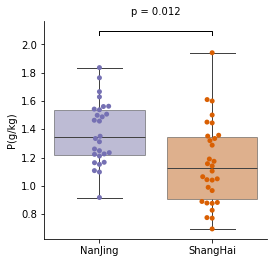

In [6]:
custom_palette = {
    'NanJing': '#7570b3',
    'ShangHai': '#d95f02'
}
fig, ax = plt.subplots(figsize=(4, 4))
ax=sns.boxplot(data=df, x="Site", y="P(g/kg)",color='white',
               palette=custom_palette,hue="Site", boxprops=dict(alpha=0.5),showfliers=False, ax=ax)
sns.swarmplot(data=df, x="Site", y="P(g/kg)",hue="Site",palette=custom_palette, ax=ax)

x1, x2 = 0, 1
y,h = df["P(g/kg)"].mean()+0.8,.03


plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="k") 

plt.text((x1+x2)*.5, y+h+.1, f'p = 0.012', ha='center', va='bottom', color="k")

ax.set_xlabel('')
ax.set_ylabel('P(g/kg)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

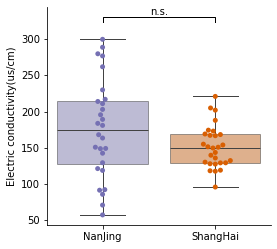

In [7]:
custom_palette = {
    'NanJing': '#7570b3',
    'ShangHai': '#d95f02'
}
fig, ax = plt.subplots(figsize=(4, 4))
ax=sns.boxplot(data=df, x="Site", y="Electric conductivity(us/cm)",color='white',
               palette=custom_palette,hue="Site", boxprops=dict(alpha=0.5),showfliers=False, ax=ax)
sns.swarmplot(data=df, x="Site", y="Electric conductivity(us/cm)",hue="Site",palette=custom_palette, ax=ax)

x1, x2 = 0, 1
y,h = df["Electric conductivity(us/cm)"].mean()+160,7

plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="k") 

plt.text((x1+x2)*.5, y+h+.1, f'n.s.', ha='center', va='bottom', color="k")

ax.set_xlabel('')
ax.set_ylabel('Electric conductivity(us/cm)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

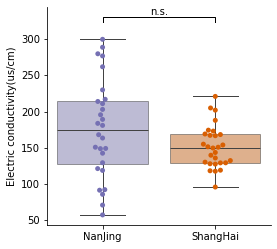

In [8]:
custom_palette = {
    'NanJing': '#7570b3',
    'ShangHai': '#d95f02'
}
fig, ax = plt.subplots(figsize=(4, 4))
ax=sns.boxplot(data=df, x="Site", y="Electric conductivity(us/cm)",color='white',
               palette=custom_palette,hue="Site", boxprops=dict(alpha=0.5),showfliers=False, ax=ax)
sns.swarmplot(data=df, x="Site", y="Electric conductivity(us/cm)",hue="Site",palette=custom_palette, ax=ax)

x1, x2 = 0, 1
y,h = df["Electric conductivity(us/cm)"].mean()+160,7

plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="k") 

plt.text((x1+x2)*.5, y+h+.1, f'n.s.', ha='center', va='bottom', color="k")

ax.set_xlabel('')
ax.set_ylabel('Electric conductivity(us/cm)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

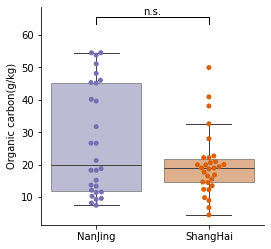

In [9]:
fig, ax = plt.subplots(figsize=(4, 4))
ax=sns.boxplot(data=df, x="Site", y="Organic carbon(g/kg)",color='white',
               palette=custom_palette,hue="Site", boxprops=dict(alpha=0.5),showfliers=False, ax=ax)
sns.swarmplot(data=df, x="Site", y="Organic carbon(g/kg)",hue="Site",palette=custom_palette, ax=ax)

x1, x2 = 0, 1
y,h = df["Organic carbon(g/kg)"].mean()+40,2

plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="k") 

plt.text((x1+x2)*.5, y+h+.1, f'n.s.', ha='center', va='bottom', color="k")

ax.set_xlabel('')
ax.set_ylabel('Organic carbon(g/kg)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

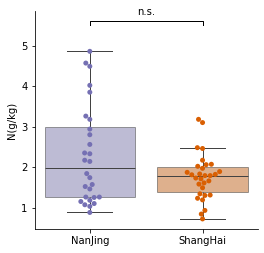

In [10]:
fig, ax = plt.subplots(figsize=(4, 4))
ax=sns.boxplot(data=df, x="Site", y="N(g/kg)",color='white',
               palette=custom_palette,hue="Site", boxprops=dict(alpha=0.5),showfliers=False, ax=ax)
sns.swarmplot(data=df, x="Site", y="N(g/kg)",hue="Site",palette=custom_palette, ax=ax)

x1, x2 = 0, 1
y,h = df["N(g/kg)"].mean()+3.5,0.09

plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="k") 

plt.text((x1+x2)*.5, y+h+.1, f'n.s.', ha='center', va='bottom', color="k")

ax.set_xlabel('')
ax.set_ylabel('N(g/kg)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

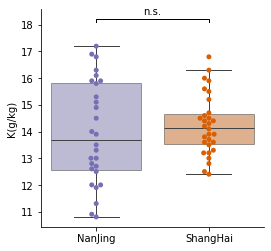

In [11]:
fig, ax = plt.subplots(figsize=(4, 4))
ax=sns.boxplot(data=df, x="Site", y="K(g/kg)",color='white',
               palette=custom_palette,hue="Site", boxprops=dict(alpha=0.5),showfliers=False, ax=ax)
sns.swarmplot(data=df, x="Site", y="K(g/kg)",hue="Site",palette=custom_palette, ax=ax)

x1, x2 = 0, 1
y,h = df["K(g/kg)"].mean()+4,0.1

plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="k") 

plt.text((x1+x2)*.5, y+h+.1, f'n.s.', ha='center', va='bottom', color="k")

ax.set_xlabel('')
ax.set_ylabel('K(g/kg)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [12]:
custom_palette = {
    'Nanjing Agricultural University_8': '#fdbf6f',
    'Sun Yat-sen Mausoleum_8': '#b2df8a',
    'Nanjing Agricultural University_5':'#ff7f00',
    'Sun Yat-sen Mausoleum_5':'#33a02c',
    'Fudan University_5':'#fb9a99',
    'Fudan University_7':'#e31a1c',
    'GongQing Forest Park':'#a6cee3',
    'HuangXing Park':'#1f78b4',
    'ShiJi Park':'#cab2d6',
}

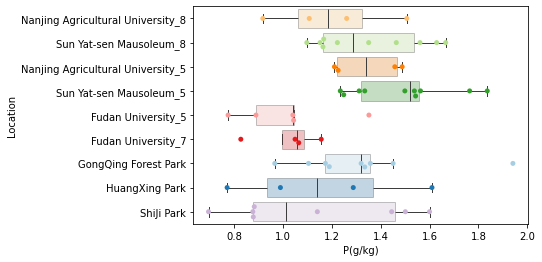

In [24]:
fig, ax = plt.subplots()
ax=sns.boxplot(data=df, x="P(g/kg)", y="Location",color='white',orient='h',palette=custom_palette,hue="Location", boxprops=dict(alpha=0.3),showfliers=False, ax=ax)
sns.swarmplot(data=df, x="P(g/kg)", y="Location",orient='h',hue="Location",palette=custom_palette, ax=ax,size=5)
plt.savefig(r'D:\soil\manuscript\draft\mine\P_all.svg')